# Problem 1: Derivation of Logistic Regression Gradient

### 1. Derive $\nabla_{\mathbf{w}} f_{\text{CE}}(\mathbf{w}, b) = -\mathbf{x}(y - \hat{y})$

#### Derivative of the Sigmoid Function
First, show that $\sigma'(z) = \sigma(z)(1 - \sigma(z))$. Given $\sigma(z) = \frac{1}{1 + e^{-z}} = (1 + e^{-z})^{-1}$:

$$\begin{aligned}
\sigma'(z) &= -(1 + e^{-z})^{-2} \cdot (-e^{-z}) \\
&= \frac{e^{-z}}{(1 + e^{-z})^2} \\
&= \left(\frac{1}{1 + e^{-z}}\right) \left(\frac{e^{-z}}{1 + e^{-z}}\right) \\
&= \left(\frac{1}{1 + e^{-z}}\right) \left(\frac{1 + e^{-z} - 1}{1 + e^{-z}}\right) \\
&= \sigma(z)(1 - \sigma(z))
\end{aligned}$$

#### Gradient of $\hat{y}$ with Respect to $\mathbf{w}$
Using $z = \mathbf{x}^\top \mathbf{w} + b$, we have $\nabla_{\mathbf{w}} z = \mathbf{x}$. Applying the chain rule:

$$\nabla_{\mathbf{w}} \hat{y} = \nabla_{\mathbf{w}} \sigma(z) = \sigma'(z) \nabla_{\mathbf{w}} z = \hat{y}(1 - \hat{y})\mathbf{x}$$

#### Gradient of Cross-Entropy Loss $f_{\text{CE}}$
The single-observation cross-entropy loss function is:
$$f_{\text{CE}}(\mathbf{w}, b) = -\left[ y \ln \hat{y} + (1 - y) \ln(1 - \hat{y}) \right]$$


$$\begin{aligned}
\nabla_{\mathbf{w}} f_{\text{CE}}(\mathbf{w}, b) &= -\left[ \frac{y}{\hat{y}} \nabla_{\mathbf{w}} \hat{y} + \frac{1 - y}{1 - \hat{y}} \nabla_{\mathbf{w}}(1 - \hat{y}) \right] \\
&= -\left[ \frac{y}{\hat{y}} - \frac{1 - y}{1 - \hat{y}} \right] \nabla_{\mathbf{w}} \hat{y}
\end{aligned}$$


$$\frac{y}{\hat{y}} - \frac{1 - y}{1 - \hat{y}} = \frac{y(1 - \hat{y}) - (1 - y)\hat{y}}{\hat{y}(1 - \hat{y})} = \frac{y - \hat{y}}{\hat{y}(1 - \hat{y})}$$

Substituting this expression and $\nabla_{\mathbf{w}} \hat{y} = \mathbf{x}\hat{y}(1 - \hat{y})$ back into the gradient:

$$\begin{aligned}
\nabla_{\mathbf{w}} f_{\text{CE}}(\mathbf{w}, b) &= -\left[ \frac{y - \hat{y}}{\hat{y}(1 - \hat{y})} \right] \mathbf{x}\hat{y}(1 - \hat{y}) \\
&= -\mathbf{x}(y - \hat{y})
\end{aligned}$$

---

### 2. Derive $\nabla_b f_{\text{CE}}(\mathbf{w}, b) = -(y - \hat{y})$


$$\frac{\partial \hat{y}}{\partial b} = \sigma'(z) \frac{\partial z}{\partial b} = \hat{y}(1 - \hat{y})$$


$$\begin{aligned}
\nabla_b f_{\text{CE}}(\mathbf{w}, b) &= -\left[ \frac{y}{\hat{y}} - \frac{1 - y}{1 - \hat{y}} \right] \frac{\partial \hat{y}}{\partial b} \\
&= -\left[ \frac{y - \hat{y}}{\hat{y}(1 - \hat{y})} \right] \hat{y}(1 - \hat{y}) \\
&= -(y - \hat{y})
\end{aligned}$$

---

### 3. Generalize to a Batch of $n$ Observations


$$f_{\text{CE}}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^n \left[ y^{(i)} \log \hat{y}^{(i)} + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

$$\nabla_{\mathbf{w}} f_{\text{CE}}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^n \mathbf{x}^{(i)} \left( y^{(i)} - \hat{y}^{(i)} \right)$$

$$\nabla_b f_{\text{CE}}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^n \left( y^{(i)} - \hat{y}^{(i)} \right)$$

## Problem 2 & 3: Numpy Implementation of Softmax Regression with Weights & Biases


In [1]:
  !pip install wandb -qq

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import wandb

def to_one_hot(labels):
    """Convert integer labels to one-hot encoding; returns one-hot array."""
    num_classes = len(set(labels))
    one_hot = np.zeros((len(labels), num_classes))
    one_hot[np.arange(len(labels)), labels] = 1 # Corrected from labels - 1
    return one_hot

def softmax(z):
    """Compute row-wise softmax; returns probability array."""
    # Subtract max for numerical stability
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    proba = exp_z / np.sum(exp_z, axis=1, keepdims=True)
    return proba

def cross_entropy_loss(W, b, images, labels, regularization_strength):
    """Compute cross-entropy loss for predictions; returns scalar loss."""
    scores = images @ W + b
    proba = softmax(scores)
    epsilon = 1e-10 # Small value to avoid log(0)
    loss = -np.sum(labels * np.log(proba + epsilon)) / images.shape[0]
    # Add L2 regularization to the loss
    loss += 0.5 * regularization_strength * np.sum(W * W)
    return loss



In [3]:
def compute_gradient(W, b, images, labels, regularization_strength):
    """Compute gradients w.r.t. weights and bias; returns (dW, db)."""
    n = images.shape[0]
    scores = images @ W + b
    proba = softmax(scores)
    error = proba - labels

    dW = (images.T @ error) / n # Gradient for weights
    dW += regularization_strength * W # Add regularization term

    db = np.sum(error, axis=0, keepdims=True) / n # Gradient for bias
    return dW, db

def compute_accuracy(W, b, images, labels):
    """Compute classification accuracy; returns fraction correct."""
    scores = images @ W + b
    predictions = np.argmax(scores, axis=1)
    true_labels = np.argmax(labels, axis=1)
    acc = np.mean(predictions == true_labels)
    return acc

def show_weights(W):
    """Render weights as image patches; returns None."""
    img_size = int(W.shape[0] ** 0.5)
    canvas = np.zeros((img_size, img_size * W.shape[1]))
    for idx, col in enumerate(range(0, canvas.shape[1], img_size)):
        canvas[:, col:col+img_size] = np.reshape(W[:, idx], (img_size, img_size))
    plt.imshow(canvas, cmap='gray')
    plt.axis('off')
    plt.title('Learned Weights')
    plt.show()

In [4]:
def train_softmax_classifier(train_images, train_labels, val_images, val_labels,
                           learning_rate=1e-5, batch_size=16, nepochs=100,
                           regularization_strength=0.0, wandb_log_enabled=True):
    """Train softmax classifier; returns (W, b, loss, accuracy)."""
    num_batches = train_images.shape[0] // batch_size
    n_features = train_images.shape[1]
    n_classes = train_labels.shape[1]

    # Initialize weights and bias
    W = np.random.randn(n_features, n_classes) * 0.01
    b = np.zeros((1, n_classes))

    cost, acc = float('inf'), 0.0

    for epoch in range(nepochs):
        np.random.seed(epoch) # For reproducibility of permutations across epochs
        perm = np.random.permutation(train_images.shape[0])
        train_images = train_images[perm]
        train_labels = train_labels[perm]

        for batch in range(num_batches):
            batch_start = batch * batch_size
            batch_end = (batch + 1) * batch_size
            batch_images = train_images[batch_start:batch_end]
            batch_labels = train_labels[batch_start:batch_end]

            # Compute gradients
            dW, db = compute_gradient(W, b, batch_images, batch_labels, regularization_strength)

            # Update weights and bias
            W -= learning_rate * dW
            b -= learning_rate * db

        # Compute validation loss and accuracy at the end of each epoch
        val_loss = cross_entropy_loss(W, b, val_images, val_labels, regularization_strength)
        val_acc = compute_accuracy(W, b, val_images, val_labels)

        if wandb_log_enabled:
            wandb.log({'epoch': epoch + 1, 'val_loss': val_loss, 'val_accuracy': val_acc})



    return W, b, val_loss, val_acc

Starting hyperparameter tuning for 9 combinations

 Running combination 1/9: {'learning_rate': 0.0001, 'regularization_strength': 0.0, 'batch_size': 64, 'epochs': 20} 


Combination 1 - Final Val Loss: 1.1080, Final Val Accuracy: 0.7086


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
val_accuracy,▁▅▆▆▆▇▇▇▇▇██████████
val_loss,█▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
epoch,20
val_accuracy,0.70858
val_loss,1.10796



 Running combination 2/9: {'learning_rate': 0.0001, 'regularization_strength': 1e-05, 'batch_size': 64, 'epochs': 20} 


Combination 2 - Final Val Loss: 1.1070, Final Val Accuracy: 0.7124


...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
val_accuracy,▁▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇████
val_loss,█▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,20
val_accuracy,0.79217
val_loss,0.6295



 Running combination 9/9: {'learning_rate': 0.001, 'regularization_strength': 0.0001, 'batch_size': 64, 'epochs': 20} 


Combination 9 - Final Val Loss: 0.6302, Final Val Accuracy: 0.7921


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
val_accuracy,▁▃▄▄▅▅▆▆▆▆▇▇▇▇▇▇████
val_loss,█▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,20
val_accuracy,0.79208
val_loss,0.63016


Best Hyperparameters found: {'learning_rate': 0.001, 'regularization_strength': 0.0, 'batch_size': 64, 'epochs': 20}
Best Validation Accuracy: 0.7922

Retraining with best hyperparameters on full training data and evaluating on test set

Final Test Loss: 0.6189
Final Test Accuracy: 0.7903


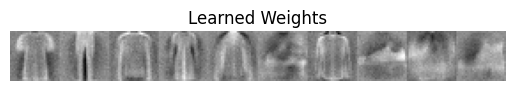

In [6]:
if __name__ == "__main__":


    # Load data
    training_images = np.load("/content/fashion_mnist_train_images.npy") / 255.0 - 0.5
    training_labels = to_one_hot(np.load("/content/fashion_mnist_train_labels.npy"))
    testing_images = np.load("/content/fashion_mnist_test_images.npy") / 255.0 - 0.5
    testing_labels = to_one_hot(np.load("/content/fashion_mnist_test_labels.npy"))

    # Split training into training and validation using train_test_split
    x_train, x_val, y_train, y_val = train_test_split(training_images,
                                                      training_labels,
                                                      test_size=0.2,
                                                      random_state=541)

    # List hyperparameters to try (9 combinations)
    learning_rates = [1e-4, 5e-4, 1e-3]
    regularization_strengths = [0.0, 1e-5, 1e-4]
    batch_size = 64 # Keeping batch size fixed for 9 combinations (3*3*1)
    nepochs_tuning = 20 # Number of epochs for hyperparameter tuning

    hyperparams_to_try = []
    for lr in learning_rates:
        for reg_s in regularization_strengths:
            hyperparams_to_try.append({
                'learning_rate': lr,
                'regularization_strength': reg_s,
                'batch_size': batch_size,
                'epochs': nepochs_tuning
            })

    # Initialize variables
    best_val_accuracy = -1.0
    best_hyperparams = {}
    final_W = None
    final_b = None

    print(f"Starting hyperparameter tuning for {len(hyperparams_to_try)} combinations")

    # Train model with different hyperparameters
    for i, params in enumerate(hyperparams_to_try):
        print(f"\n Running combination {i+1}/{len(hyperparams_to_try)}: {params} ")
        wandb.init(project="cs541-hw2-fashion-mnist",
                   config=params,
                   tags=["hp_sweep"],
                   notes=f"Run for LR={params['learning_rate']}, Reg={params['regularization_strength']}")

        W, b, val_loss, val_acc = train_softmax_classifier(
            x_train, y_train, x_val, y_val,
            learning_rate=params['learning_rate'],
            batch_size=params['batch_size'],
            nepochs=params['epochs'],
            regularization_strength=params['regularization_strength'],
            wandb_log_enabled=True
        )

        print(f"Combination {i+1} - Final Val Loss: {val_loss:.4f}, Final Val Accuracy: {val_acc:.4f}")

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_hyperparams = params


        wandb.finish()

    print(f"Best Hyperparameters found: {best_hyperparams}")
    print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")

    print("\nRetraining with best hyperparameters on full training data and evaluating on test set")
    # For final evaluation, want more epochs or a different batch size
    final_W, final_b, test_loss, test_acc = train_softmax_classifier(
        training_images, training_labels, testing_images, testing_labels,
        learning_rate=best_hyperparams['learning_rate'],
        batch_size=best_hyperparams['batch_size'],
        nepochs=best_hyperparams['epochs'], # Use the epochs from the best run
        regularization_strength=best_hyperparams['regularization_strength'],
        wandb_log_enabled=False # Explicitly disable W&B for final run
    )

    print(f"\nFinal Test Loss: {test_loss:.4f}")
    print(f"Final Test Accuracy: {test_acc:.4f}")


    show_weights(final_W)


## Problem 4: Affine Transformations and Gradient Calculation

### 1. Representation as Affine Transformations

$W\mathbf{x} + \mathbf{b}$


$$g\left(\begin{bmatrix} x_1 \\ x_2 \end{bmatrix}\right) = \begin{bmatrix} 1 & 2 \\ 0 & 1 \\ -1 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} 0 \\ 0 \\ 3 \end{bmatrix} \implies W_1 = \begin{bmatrix} 1 & 2 \\ 0 & 1 \\ -1 & 0 \end{bmatrix}, \quad \mathbf{b}_1 = \begin{bmatrix} 0 \\ 0 \\ 3 \end{bmatrix}$$


$$f\left(\begin{bmatrix} z_{1,1} \\ z_{1,2} \\ z_{1,3} \end{bmatrix}\right) = \begin{bmatrix} 1 & -2 & 0.25 \end{bmatrix} \begin{bmatrix} z_{1,1} \\ z_{1,2} \\ z_{1,3} \end{bmatrix} + \begin{bmatrix} 0 \end{bmatrix} \implies W_2 = \begin{bmatrix} 1 & -2 & 0.25 \end{bmatrix}, \quad \mathbf{b}_2 = \begin{bmatrix} 0 \end{bmatrix}$$

### 2. Python Function AffineTransformation(W, b, x)

In [7]:
import numpy as np

def AffineTransformation(W, b, x):
    """Computes z = Wx + b."""
    return W @ x + b

### 3. Python Function Composition(L, x)

In [8]:
def Composition(L, x):
    """Calculates sequential affine transformations from L = [(W1, b1), ..., (Wn, bn)].
    Returns list of intermediate activation vectors z = [z1, z2, ..., zn].
    """
    z_list = []
    current_x = x
    for W, b in L:
        current_x = AffineTransformation(W, b, current_x)
        z_list.append(current_x)
    return z_list

### 4. Calling Composition for $(f \circ g)(\mathbf{x})$

In [9]:
W1 = np.array([[1.0, 2.0],
               [0.0, 1.0],
               [-1.0, 0.0]])
b1 = np.array([0.0, 0.0, 3.0])

W2 = np.array([[1.0, -2.0, 0.25]])
b2 = np.array([0.0])

L = [(W1, b1), (W2, b2)]
x = np.array([-1.0, 1.0])

final_output = Composition(L, x)[-1]
print(final_output)  # Output: [-0.0] (or [0.0])

[0.]


### Calculation verification:

$\mathbf{z}_1 = g\left(\begin{bmatrix} -1 \\ 1 \end{bmatrix}\right) = \begin{bmatrix} 1(-1)+2(1) \\ 1 \\ -(-1)+3 \end{bmatrix} = \begin{bmatrix} 1 \\ 1 \\ 4 \end{bmatrix}$

$z_2 = f\left(\begin{bmatrix} 1 \\ 1 \\ 4 \end{bmatrix}\right) = 1(1) - 2(1) + 0.25(4) = 0$

Final Output: [0.0]

### 5. Derive Derivatives for $z_2 = f(z_1)$

For an affine mapping $\mathbf{z}_2 = W_2 \mathbf{z}_1 + \mathbf{b}_2$:

**Derivative w.r.t. $\mathbf{b}_2$**:

Since $\frac{\partial \mathbf{z}_2}{\partial \mathbf{b}_2} = I$ (the identity matrix), for scalar $z_2$:

$$\frac{\partial z_2}{\partial \mathbf{b}_2} = 1$$

**Derivative w.r.t. $\text{vec}[W_2]$**:

Using the vector identity $\text{vec}(AXB) = (B^\top \otimes A)\text{vec}(X)$:

$$z_2 = (\mathbf{z}_1^\top \otimes I_1)\text{vec}[W_2] + \mathbf{b}_2 = \mathbf{z}_1^\top \text{vec}[W_2] + \mathbf{b}_2$$

$$\frac{\partial z_2}{\partial \text{vec}[W_2]}(\mathbf{z}_1) = \mathbf{z}_1^\top$$

### 6. Equation for $\frac{\partial(f \circ g)}{\partial \mathbf{z}_1}(\mathbf{x})$

$$\frac{\partial (f \circ g)}{\partial \mathbf{z}_1}(\mathbf{x}) = \frac{\partial f}{\partial \mathbf{z}_1}(\mathbf{z}_1) = W_2 = \begin{bmatrix} 1 & -2 & 0.25 \end{bmatrix}$$

### 7. Equations for $\frac{\partial(f \circ g)}{\partial \mathbf{b}_1}$ and $\nabla_{W_1}(f \circ g)(\mathbf{x})$ [2 pts]

Let $\mathbf{p}^\top = \frac{\partial (f \circ g)}{\partial \mathbf{z}_1} = W_2$:

**Gradient w.r.t. bias $\mathbf{b}_1$**:

$$\frac{\partial(f \circ g)}{\partial \mathbf{b}_1} = \frac{\partial y}{\partial \mathbf{z}_1} \frac{\partial \mathbf{z}_1}{\partial \mathbf{b}_1} = W_2 \cdot I = W_2$$

$$\nabla_{\mathbf{b}_1}(f \circ g)(\mathbf{x}) = \left(\frac{\partial(f \circ g)}{\partial \mathbf{b}_1}\right)^\top = W_2^\top$$

**Gradient w.r.t. weights $W_1$**:

$$\nabla_{W_1}(f \circ g)(\mathbf{x}) = \mathbf{p}\mathbf{x}^\top = W_2^\top \mathbf{x}^\top$$

### 8. Python Function ComputeGradients(L, x, z)

In [11]:
def ComputeGradients(L, x, z):
    """Computes gradients of scalar z_n w.r.t. all parameters in L.

    Args:
        L: List of tuples [(W1, b1), ..., (Wn, bn)]
        x: Initial input vector
        z: List of activations [z1, z2, ..., zn] from Composition

    Returns:
        grads: List of tuples [(grad_W1, grad_b1), ..., (grad_Wn, grad_bn)]
    """
    n = len(L)
    grads = [None] * n

    p = np.array([1.0])

    # Backpropagate through layers
    for i in range(n - 1, -1, -1):
        W_i, b_i = L[i]

        prev_activation = z[i - 1] if i > 0 else x

        # Gradients for layer i parameters
        grad_b = p.copy()
        grad_W = np.outer(p, prev_activation)

        grads[i] = (grad_W, grad_b)

        if i > 0:
            p = W_i.T @ p

    return grads